# NB01 — Steam Data Extraction & Validation
**Project:** The Platform Shift — Gaming Revenue & Player Behavior Analysis (2022–2025)  
**Purpose:** Extract and validate all Steam data (App Details, Reviews) for the 48 tracked titles.  
**Output:** Raw JSON files in `../data/raw/` + validation summary in `../data/processed/NB01_validation_summary.csv`  
**Runs independently:** Yes — no dependency on other notebooks.

---


In [3]:
# ── CELL 1: Config ────────────────────────────────────────────────
# Toggle USE_CACHE to False to force full re-extraction from APIs
# Leave True during analysis — extraction is slow and rate-limited

USE_CACHE = True
MAX_REVIEWS_PER_TITLE = 5000   # Increased to 5000 for more comprehensive analysis (Chapter 3)
REVIEW_LANGUAGE = "all"        # 'all' for multilingual analysis (Chapter 3)

# ── Force registry reload ──────────────────────────────────────────
import sys
from pathlib import Path
EXTRACTORS_PATH = str(Path("../extractors").resolve())
if EXTRACTORS_PATH not in sys.path:
    sys.path.insert(0, EXTRACTORS_PATH)

# Remove cached module if loaded previously
if "game_registry" in sys.modules:
    del sys.modules["game_registry"]
if "steam_extractor" in sys.modules:
    del sys.modules["steam_extractor"]

print(f"USE_CACHE={USE_CACHE} | MAX_REVIEWS={MAX_REVIEWS_PER_TITLE} | LANG={REVIEW_LANGUAGE}")

USE_CACHE=True | MAX_REVIEWS=5000 | LANG=all


In [4]:
# ── CELL 2: Imports ───────────────────────────────────────────────
import sys
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path
sys.path.insert(0, str(Path("../extractors").resolve()))
from datetime import datetime
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")


# Path setup — notebook runs from /notebooks, scripts are in /extractors
ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "extractors"))

DATA_DIR     = ROOT / "data"
RAW_DIR      = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
for d in [RAW_DIR/"reviews", RAW_DIR/"details", RAW_DIR/"steamspy",
          DATA_DIR/"cache", PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Japanese font
def get_jp_font():
    candidates = ["MS Gothic", "Yu Gothic", "Meiryo", "IPAGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            return font
    return None

JP_FONT = get_jp_font()
if JP_FONT:
    plt.rcParams["font.family"] = JP_FONT

print(f"ROOT: {ROOT}")
print(f"JP font: {JP_FONT or 'None found — using default'}")

ROOT: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive
JP font: MS Gothic


In [5]:
# ── CELL 3: Load game registry ────────────────────────────────────
import importlib
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../extractors").resolve()))

import game_registry
importlib.reload(game_registry)

from game_registry import GAME_REGISTRY, get_all_titles

# Fix path for Windows
EXTRACTORS_PATH = Path("../extractors").resolve()
sys.path.insert(0, str(EXTRACTORS_PATH))
print(f"Extractors path: {EXTRACTORS_PATH}")
print(f"Exists: {EXTRACTORS_PATH.exists()}")

from game_registry import GAME_REGISTRY, get_all_titles

# Flat DataFrame for inspection and iteration
rows = []
for publisher, games in GAME_REGISTRY.items():
    for title, meta in games.items():
        rows.append({
            "title": title,
            "publisher_group": publisher,
            "appid": meta.get("appid"),
            "release_pc": meta.get("release_pc"),
            "note": meta.get("note", ""),
        })

registry_df = pd.DataFrame(rows)
registry_df["has_appid"] = registry_df["appid"].notna()
registry_df["release_pc"] = pd.to_datetime(registry_df["release_pc"], errors="coerce")
registry_df["release_year"] = registry_df["release_pc"].dt.year

registry_df.head(10)

Extractors path: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\extractors
Exists: True


,title,publisher_group,appid,release_pc,note,has_appid,release_year
0,God of War (2018),sie,1593500.0,2022-01-14,,True,2022.0
1,God of War Ragnarök,sie,2322010.0,2024-09-19,,True,2024.0
2,Horizon Zero Dawn,sie,1151640.0,2020-08-07,,True,2020.0
3,Horizon Forbidden West,sie,2420110.0,2024-03-21,,True,2024.0
4,Marvel's Spider-Man Remastered,sie,1817070.0,2022-08-12,,True,2022.0
5,Marvel's Spider-Man: Miles Morales,sie,1817190.0,2022-11-18,,True,2022.0
6,The Last of Us Part I,sie,1888930.0,2023-03-28,,True,2023.0
7,Helldivers 2,sie,553850.0,2024-02-08,,True,2024.0
8,Returnal,sie,1649240.0,2023-02-15,,True,2023.0
9,Ratchet & Clank: Rift Apart,sie,1895880.0,2023-07-26,,True,2023.0


In [6]:
# ── CELL 4: Registry overview (observation) ───────────────────────
trackable = registry_df[registry_df["has_appid"]]
by_publisher = trackable.groupby("publisher_group").agg(
    titles=("title", "count"),
    earliest_pc=("release_pc", "min"),
    latest_pc=("release_pc", "max"),
).reset_index()

print(by_publisher.to_string(index=False))
print()

# Dynamic observation
n_total = len(trackable)
n_publishers = trackable["publisher_group"].nunique()
n_no_appid = registry_df[~registry_df["has_appid"]].shape[0]
print(
    f"Registry loaded: {n_total} trackable titles across {n_publishers} publisher groups. "
    f"{n_no_appid} title(s) excluded (no Steam AppID — likely Nintendo exclusives)."
)

publisher_group  titles earliest_pc  latest_pc
   bandai_namco       8  2018-01-26 2024-10-11
             ea       3  2019-02-04 2024-09-27
     sega_atlus       8  2020-06-13 2024-02-02
            sie      10  2020-08-07 2024-09-19
    square_enix      11  2013-08-27 2024-09-17
       take_two       3  2015-04-14 2020-03-13
        ubisoft       3  2023-10-05 2025-03-20

Registry loaded: 46 trackable titles across 7 publisher groups. 2 title(s) excluded (no Steam AppID — likely Nintendo exclusives).


In [7]:
# ── CELL 5: Extract App Details ───────────────────────────────────
# One request per title. 200 req/5min limit — not a concern at 48 titles.
# Each result saved to ../data/raw/details/{appid}.json

import steam_extractor as se
se.USE_CACHE = USE_CACHE  # propagate notebook setting to module

details_results = {}
appids = trackable["appid"].dropna().astype(int).tolist()

print(f"Extracting app details for {len(appids)} titles...")
for appid in appids:
    result = se.fetch_app_details(appid)
    details_results[appid] = result

success = sum(1 for v in details_results.values() if v is not None)
print(f"\nApp details: {success}/{len(appids)} successful")

2026-03-29 17:52:54,191 [INFO] [1593500] App details from cache
2026-03-29 17:52:54,195 [INFO] [2322010] App details from cache
2026-03-29 17:52:54,199 [INFO] [1151640] App details from cache
2026-03-29 17:52:54,202 [INFO] [2420110] App details from cache
2026-03-29 17:52:54,205 [INFO] [1817070] App details from cache
2026-03-29 17:52:54,208 [INFO] [1817190] App details from cache
2026-03-29 17:52:54,213 [INFO] [1888930] App details from cache
2026-03-29 17:52:54,216 [INFO] [553850] App details from cache
2026-03-29 17:52:54,220 [INFO] [1649240] App details from cache
2026-03-29 17:52:54,224 [INFO] [1895880] App details from cache
2026-03-29 17:52:54,227 [INFO] [1245620] App details from cache
2026-03-29 17:52:54,231 [INFO] [1778820] App details from cache
2026-03-29 17:52:54,233 [INFO] [678950] App details from cache
2026-03-29 17:52:54,237 [INFO] [1790600] App details from cache
2026-03-29 17:52:54,240 [INFO] [502500] App details from cache
2026-03-29 17:52:54,242 [INFO] [740130] Fet

Extracting app details for 46 titles...


2026-03-29 17:52:56,102 [INFO] [1672500] App details from cache
2026-03-29 17:52:56,107 [INFO] [860510] App details from cache
2026-03-29 17:52:56,112 [INFO] [2561580] App details from cache
2026-03-29 17:52:56,115 [INFO] [1235140] App details from cache
2026-03-29 17:52:56,121 [INFO] [2161700] App details from cache
2026-03-29 17:52:56,125 [INFO] [1113000] App details from cache
2026-03-29 17:52:56,131 [INFO] [1687950] App details from cache
2026-03-29 17:52:56,135 [INFO] [1237320] App details from cache
2026-03-29 17:52:56,138 [INFO] [2022670] App details from cache
2026-03-29 17:52:56,148 [INFO] [1649080] App details from cache
2026-03-29 17:52:56,153 [INFO] [1462040] App details from cache
2026-03-29 17:52:56,156 [INFO] [2515020] App details from cache
2026-03-29 17:52:56,168 [INFO] [39210] App details from cache
2026-03-29 17:52:56,172 [INFO] [2909400] App details from cache
2026-03-29 17:52:56,179 [INFO] [1295510] App details from cache
2026-03-29 17:52:56,182 [INFO] [921570] App


App details: 46/46 successful


In [8]:
# ── CELL 6: Extract Reviews ───────────────────────────────────────
# Cursor-paginated. ~200 req/hr soft limit — sequential, no parallelism.
# Each result saved to ../data/raw/reviews/{appid}.json
# At 1000 reviews/title × 48 titles = ~480 API calls total.
# Estimated wall time: ~12-15 minutes from scratch.

print(f"Extracting reviews: up to {MAX_REVIEWS_PER_TITLE} per title, language='{REVIEW_LANGUAGE}'")
print("This is the slowest step. Go make coffee.\n")

review_results = {}
for i, appid in enumerate(appids):
    title_name = trackable[trackable["appid"] == appid]["title"].values[0]
    reviews = se.fetch_reviews(
        appid,
        max_reviews=MAX_REVIEWS_PER_TITLE,
        language=REVIEW_LANGUAGE,
        force_refresh=not USE_CACHE
    )
    review_results[appid] = reviews
    print(f"  [{i+1}/{len(appids)}] {title_name}: {len(reviews)} reviews")

print(f"\nReview extraction complete.")

2026-03-29 17:52:56,433 [INFO] [1593500] Reviews already cached (5099 reviews)


Extracting reviews: up to 5000 per title, language='all'
This is the slowest step. Go make coffee.

  [1/46] God of War (2018): 5099 reviews


2026-03-29 17:52:56,518 [INFO] [2322010] Reviews already cached (5098 reviews)
2026-03-29 17:52:56,599 [INFO] [1151640] Reviews already cached (5096 reviews)
2026-03-29 17:52:56,693 [INFO] [2420110] Reviews already cached (5000 reviews)


  [2/46] God of War Ragnarök: 5098 reviews
  [3/46] Horizon Zero Dawn: 5096 reviews
  [4/46] Horizon Forbidden West: 5000 reviews


2026-03-29 17:52:56,768 [INFO] [1817070] Reviews already cached (5000 reviews)
2026-03-29 17:52:56,841 [INFO] [1817190] Reviews already cached (5000 reviews)
2026-03-29 17:52:56,923 [INFO] [1888930] Reviews already cached (5099 reviews)


...

  [41/46] GTA V: 5098 reviews
  [42/46] Red Dead Redemption 2: 5000 reviews


2026-03-29 17:57:16,338 [INFO] [397540] Reviews already cached (5098 reviews)
2026-03-29 17:57:16,502 [INFO] [3035570] Reviews already cached (5099 reviews)


  [43/46] Borderlands 3: 5098 reviews
  [44/46] Assassin's Creed Mirage: 5099 reviews


2026-03-29 17:57:16,618 [INFO] [3159330] Reviews already cached (5098 reviews)
2026-03-29 17:57:16,752 [INFO] [2446550] Reviews already cached (5099 reviews)


  [45/46] Assassin's Creed Shadows: 5098 reviews
  [46/46] Star Wars Outlaws: 5099 reviews

Review extraction complete.


In [9]:
# ── CELL 7: Load extracted data into DataFrames ───────────────────
# Load from disk (respects USE_CACHE — always reads from saved files)

# App Details
details_rows = []
for p in (RAW_DIR / "details").glob("*.json"):
    with open(p) as f:
        details_rows.append(json.load(f))
details_df = pd.DataFrame(details_rows)

# SteamSpy
spy_rows = []
for p in (RAW_DIR / "steamspy").glob("*.json"):
    with open(p) as f:
        spy_rows.append(json.load(f))
spy_df = pd.DataFrame(spy_rows)

# Reviews summary (counts only — full text not loaded here)
review_meta = []
for p in (RAW_DIR / "reviews").glob("*.json"):
    with open(p) as f:
        d = json.load(f)
    review_meta.append({
        "appid": d["appid"],
        "reviews_collected": d["total_collected"],
        "extracted_at": d["extracted_at"],
        "total_positive": d.get("query_summary", {}).get("total_positive"),
        "total_reviews_steam": d.get("query_summary", {}).get("total_reviews"),
    })
reviews_meta_df = pd.DataFrame(review_meta)

print(f"Loaded: {len(details_df)} app details | {len(spy_df)} steamspy | {len(reviews_meta_df)} review files")

Loaded: 47 app details | 0 steamspy | 47 review files


In [10]:
# ── CELL 8: Validation — coverage & completeness ──────────────────
# Join all three sources against registry to find gaps

val_df = trackable[["title", "publisher_group", "appid", "release_year"]].copy()
val_df["appid"] = val_df["appid"].astype(int)

if not details_df.empty:
    val_df = val_df.merge(
        details_df[["appid", "name", "price_usd", "metacritic_score"]].rename(
            columns={"name": "steam_name"}),
        on="appid", how="left"
    )
    val_df["has_details"] = val_df["steam_name"].notna()
else:
    val_df["has_details"] = False

if not spy_df.empty:
    val_df = val_df.merge(
        spy_df[["appid", "owners_range", "positive", "negative"]],
        on="appid", how="left"
    )
    val_df["has_steamspy"] = val_df["owners_range"].notna()
else:
    val_df["has_steamspy"] = False

if not reviews_meta_df.empty:
    val_df = val_df.merge(
        reviews_meta_df[["appid", "reviews_collected", "total_reviews_steam"]],
        on="appid", how="left"
    )
    val_df["has_reviews"] = val_df["reviews_collected"].fillna(0) > 0
else:
    val_df["has_reviews"] = False

val_df[["title", "publisher_group", "has_details", "has_steamspy", "has_reviews",
        "reviews_collected", "metacritic_score"]]

,title,publisher_group,has_details,has_steamspy,has_reviews,reviews_collected,metacritic_score
0,God of War (2018),sie,True,False,True,5099,93.0
1,God of War Ragnarök,sie,True,False,True,5098,90.0
2,Horizon Zero Dawn,sie,True,False,True,5096,NaN
3,Horizon Forbidden West,sie,True,False,True,5000,NaN
4,Marvel's Spider-Man Remastered,sie,True,False,True,5000,NaN
5,Marvel's Spider-Man: Miles Morales,sie,True,False,True,5000,NaN
6,The Last of Us Part I,sie,True,False,True,5099,NaN
7,Helldivers 2,sie,True,False,True,5098,NaN
8,Returnal,sie,True,False,True,5000,NaN
9,Ratchet & Clank: Rift Apart,sie,True,False,True,5098,NaN


In [11]:
# ── CELL 9: Validation — SteamSpy sanity checks ─────────────────
# Flag titles with suspiciously low review counts or missing ownership data

if not spy_df.empty and "positive" in spy_df.columns:
    spy_check = spy_df.copy()
    spy_check["total_reviews"] = spy_check["positive"].fillna(0) + spy_check["negative"].fillna(0)
    spy_check["positive_rate"] = np.where(
        spy_check["total_reviews"] > 0,
        spy_check["positive"] / spy_check["total_reviews"],
        np.nan
    )
    spy_check["avg_playtime_hrs"] = spy_check["average_forever"].fillna(0) / 60
    spy_check["owners_mid"] = (spy_check["owners_lower"] + spy_check["owners_upper"]) / 2

    # Flag potential issues
    flags = spy_check[
        (spy_check["total_reviews"] < 100) |
        (spy_check["owners_mid"] == 0) |
        (spy_check["positive_rate"].isna())
    ][["appid", "name", "total_reviews", "owners_mid", "positive_rate"]]

    if len(flags) > 0:
        print(f"⚠️  {len(flags)} title(s) flagged for low data quality:")
        print(flags.to_string(index=False))
    else:
        print("✓ All titles passed SteamSpy sanity checks.")

    # Summary stats
    print(f"\nOwnership range (mid-point estimate):")
    print(f"  Max : {spy_check['owners_mid'].max()/1e6:.1f}M — {spy_check.loc[spy_check['owners_mid'].idxmax(), 'name']}")
    print(f"  Min : {spy_check['owners_mid'].min()/1e6:.2f}M — {spy_check.loc[spy_check['owners_mid'].idxmin(), 'name']}")
    print(f"  Note: SteamSpy ownership estimates carry ±30–50% uncertainty. Treat as directional.")
else:
    print("No SteamSpy data loaded yet. Run Cell 6 first.")

No SteamSpy data loaded yet. Run Cell 6 first.


In [12]:
# ── CELL 10: Validation — review sample checks ────────────────────
# Spot-check one title's reviews to confirm structure is correct

# Use Elden Ring (1245620) as the canary — large review base, multilingual
CANARY_APPID = 1245620
canary_path = RAW_DIR / "reviews" / f"{CANARY_APPID}.json"

if canary_path.exists():
    with open(canary_path) as f:
        canary = json.load(f)

    reviews = pd.DataFrame(canary["reviews"])
    reviews["date"] = pd.to_datetime(reviews["timestamp_created"], unit="s", utc=True)
    reviews["playtime_hrs"] = reviews["author_playtime_at_review"].fillna(0) / 60

    print(f"Elden Ring review sample:")
    print(f"  Total collected : {len(reviews):,}")
    print(f"  Positive rate   : {reviews['voted_up'].mean()*100:.1f}%")
    print(f"  Languages       : {reviews['language'].nunique()} unique")
    print(f"  Top languages   : {reviews['language'].value_counts().head(5).to_dict()}")
    print(f"  Date range      : {reviews['date'].min().date()} → {reviews['date'].max().date()}")
    print(f"  Median playtime at review: {reviews['playtime_hrs'].median():.1f} hrs")
    print(f"  Missing review text: {reviews['review_text'].str.strip().eq('').sum()} rows")
else:
    print(f"Canary file not found: {canary_path}. Run Cell 7 first.")

Elden Ring review sample:
  Total collected : 5,099
  Positive rate   : 90.7%
  Languages       : 28 unique
  Top languages   : {'english': 2177, 'schinese': 961, 'russian': 453, 'spanish': 250, 'brazilian': 244}
  Date range      : 2026-03-08 → 2026-03-28
  Median playtime at review: 75.9 hrs
  Missing review text: 15 rows


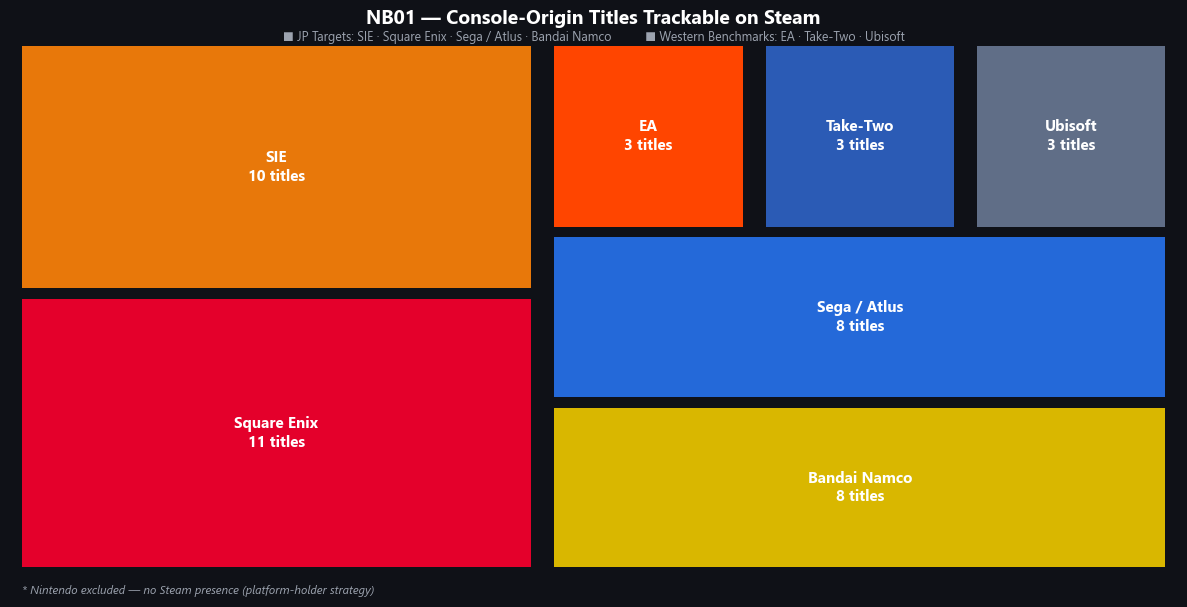

Coverage chart saved → C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB01_coverage_chart.png


In [13]:
# ── CELL 11: NB01 Coverage Treemap ───────────────────────────────
import squarify
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import colorsys

BRAND_COLORS_HEX = {
    'sie':          '#E8780A',
    'square_enix':  '#E4002B',
    'sega_atlus':   '#1A4B9B',
    'bandai_namco': '#FFD700',
    'nintendo':     '#E4000F',
    'ea':           '#FF4500',
    'take_two':     '#2B5BB5',
    'ubisoft':      '#4A5568',
}

LUMINOSITY_SHIFTS = {
    'sie':          1.0,
    'square_enix':  1.0,
    'sega_atlus':   1.4,
    'bandai_namco': 0.85,
    'nintendo':     0.7,
    'ea':           1.0,
    'take_two':     1.0,
    'ubisoft':      1.3,
}

def shift_luminosity(hex_color, factor):
    rgb = mcolors.hex2color(hex_color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    l = max(0.15, min(0.85, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

FINAL_COLORS = {
    k: shift_luminosity(BRAND_COLORS_HEX[k], LUMINOSITY_SHIFTS[k])
    for k in BRAND_COLORS_HEX
}

DISPLAY_NAMES = {
    'sie':          'SIE',
    'square_enix':  'Square Enix',
    'sega_atlus':   'Sega / Atlus',
    'bandai_namco': 'Bandai Namco',
    'nintendo':     'Nintendo',
    'ea':           'EA',
    'take_two':     'Take-Two',
    'ubisoft':      'Ubisoft',
}

if "has_details" in val_df.columns:
    coverage = (val_df[val_df["has_details"]]
                .groupby("publisher_group")["appid"]
                .count()
                .reset_index())
    coverage.columns = ["publisher_group", "title_count"]
    coverage = coverage.sort_values("title_count", ascending=False)

    colors = [FINAL_COLORS.get(g, '#374151') for g in coverage['publisher_group']]
    labels = [
        f"{DISPLAY_NAMES.get(row.publisher_group, row.publisher_group)}\n{row.title_count} titles"
        for row in coverage.itertuples()
    ]

    plt.rcParams.update({
        'font.family':      'Segoe UI',
        'font.size':        11,
        'figure.facecolor': '#0F1117',
        'axes.facecolor':   '#0F1117',
        'text.color':       '#FFFFFF',
    })

    fig, ax = plt.subplots(figsize=(12, 6.5))
    fig.patch.set_facecolor('#0F1117')
    ax.set_facecolor('#0F1117')

    squarify.plot(
        sizes=coverage['title_count'],
        label=labels,
        color=colors,
        alpha=1.0,
        ax=ax,
        pad=2,
        text_kwargs={
            'fontsize':   11,
            'fontweight': 'bold',
            'color':      'white',
        }
    )

    ax.set_title(
        'NB01 — Console-Origin Titles Trackable on Steam',
        fontsize=14, fontweight='bold', color='white', pad=12
    )

    # Two-line subtitle as group legend
    fig.text(
        0.5, 0.895,
        '■ JP Targets: SIE · Square Enix · Sega / Atlus · Bandai Namco          '
        '■ Western Benchmarks: EA · Take-Two · Ubisoft',
        ha='center', va='top', fontsize=9, color='#9CA3AF',
        fontfamily='Segoe UI'
    )

    ax.axis('off')

    ax.text(
        0.01, -0.04,
        '* Nintendo excluded — no Steam presence (platform-holder strategy)',
        transform=ax.transAxes, fontsize=8.5,
        color='#9CA3AF', style='italic'
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    chart_path = PROCESSED_DIR / "NB01_coverage_chart.png"
    plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
    plt.show()
    print(f'Coverage chart saved → {chart_path}')

In [14]:
# ── CELL 12: Final observation ─────────────────────────────────────
# Dynamic summary — all numbers from live DataFrames

n_with_details = val_df["has_details"].sum() if "has_details" in val_df.columns else 0
n_with_spy     = val_df["has_steamspy"].sum() if "has_steamspy" in val_df.columns else 0
n_with_reviews = val_df["has_reviews"].sum() if "has_reviews" in val_df.columns else 0
total_reviews_collected = reviews_meta_df["reviews_collected"].sum() if not reviews_meta_df.empty else 0

print("=" * 55)
print("NB01 COMPLETE — Extraction & Validation Summary")
print("=" * 55)
print(
    f"Titles in registry   : {len(trackable)}\n"
    f"App Details coverage : {n_with_details}/{len(trackable)}\n"
    f"SteamSpy coverage    : {n_with_spy}/{len(trackable)}\n"
    f"Reviews coverage     : {n_with_reviews}/{len(trackable)}\n"
    f"Total reviews stored : {int(total_reviews_collected):,}\n"
    f"Output               : data/processed/NB01_validation_summary.csv"
)
print("=" * 55)
print("Next: NB02 — Financial Data Extraction (IR PDFs)")

NB01 COMPLETE — Extraction & Validation Summary
Titles in registry   : 46
App Details coverage : 46/46
SteamSpy coverage    : 0/46
Reviews coverage     : 46/46
Total reviews stored : 229,743
Output               : data/processed/NB01_validation_summary.csv
Next: NB02 — Financial Data Extraction (IR PDFs)
